# Algorithms in ySights

This tutorial covers the analytical algorithms available in ySights for understanding simulation dynamics.

## What You'll Learn

- Profile similarity analysis
- Visibility paradox detection
- Recommendation system metrics

---

In [15]:
from ysights import YDataHandler
from ysights.algorithms import (
    profile_topics_similarity,
    visibility_paradox,
    user_visibility_vs_neighbors,
    visibility_paradox_population_size_null,
    engagement_momentum,
    personalization_balance_score,
)
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [16]:
# Initialize data handler and get network
db_path = 'ysocial_db.db'
ydh = YDataHandler(db_path)
network = ydh.social_network()

## 1. Profile Similarity Analysis

Analyzes how similar users' interest profiles are across the network.

In [17]:
# Calculate profile similarity
# This computes cosine similarity between users' topic interest profiles
similarity_scores = profile_topics_similarity(ydh, network)

# Convert dictionary values to list for statistics
similarity_values = list(similarity_scores.values())

print(f"Computed {len(similarity_scores)} similarity scores")
print(f"\nSimilarity Statistics:")
print(f"  Mean: {np.mean(similarity_values):.4f}")
print(f"  Median: {np.median(similarity_values):.4f}")
print(f"  Std Dev: {np.std(similarity_values):.4f}")
print(f"  Min: {min(similarity_values):.4f}")
print(f"  Max: {max(similarity_values):.4f}")

Computed 949 similarity scores

Similarity Statistics:
  Mean: 0.8509
  Median: 0.9048
  Std Dev: 0.1667
  Min: 0.1600
  Max: 1.0000


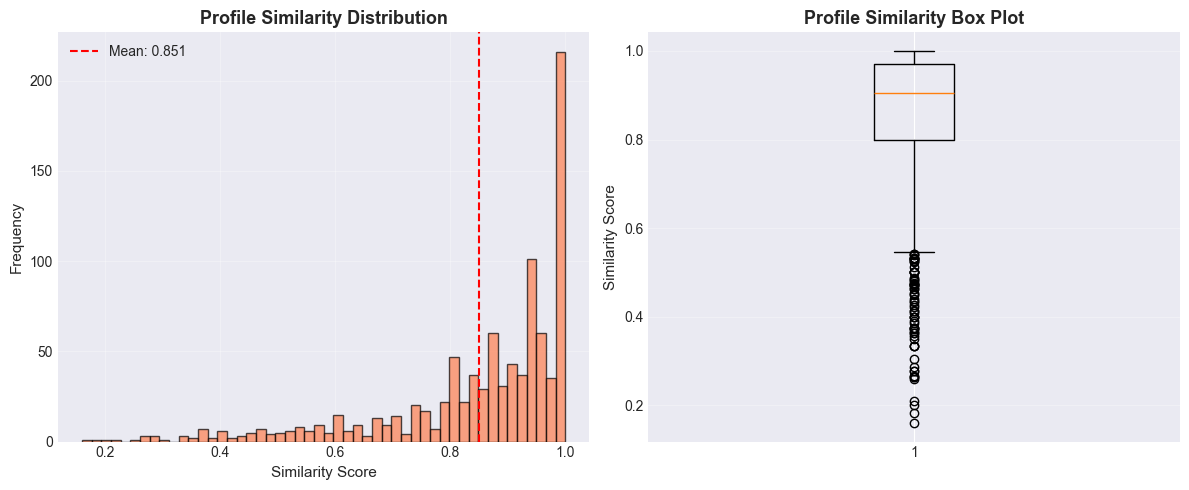

In [18]:
# Visualize similarity distribution
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(similarity_values, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Similarity Score', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Profile Similarity Distribution', fontsize=13, fontweight='bold')
plt.axvline(np.mean(similarity_values), color='red', linestyle='--', 
            label=f'Mean: {np.mean(similarity_values):.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(similarity_values, vert=True)
plt.ylabel('Similarity Score', fontsize=11)
plt.title('Profile Similarity Box Plot', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 2. Visibility Paradox Analysis

The visibility paradox occurs when users' posts receive less visibility than their friends' posts on average.

In [19]:
# Analyze visibility paradox
# N is the sample size (use smaller number for faster computation)
paradox_results = visibility_paradox(ydh, network, N=100)

print("Visibility Paradox Results:")
print(f"  Paradox Score: {paradox_results['paradox_score']:.4f}")
print(f"  Z-score: {paradox_results['z_score']:.4f}")
print(f"  P-value: {paradox_results['p_value']:.4f}")

Visibility Paradox Results:
  Paradox Score: 0.2304
  Z-score: 322.9288
  P-value: 0.0000


### User Visibility vs. Neighbors' Visibility

In [20]:
# Get detailed visibility comparison
user_vis, neighbor_vis = user_visibility_vs_neighbors(ydh, network)

print(f"Analyzed {len(user_vis)} users")
print(f"\nAverage User Visibility: {np.mean(user_vis):.2f}")
print(f"Average Neighbor Visibility: {np.mean(neighbor_vis):.2f}")

# Count users experiencing paradox
paradox_count = sum(1 for u, n in zip(user_vis, neighbor_vis) if u < n)
print(f"\nUsers experiencing paradox: {paradox_count} ({100*paradox_count/len(user_vis):.1f}%)")

Analyzed 975 users

Average User Visibility: 18.11
Average Neighbor Visibility: 18.59

Users experiencing paradox: 630 (64.6%)


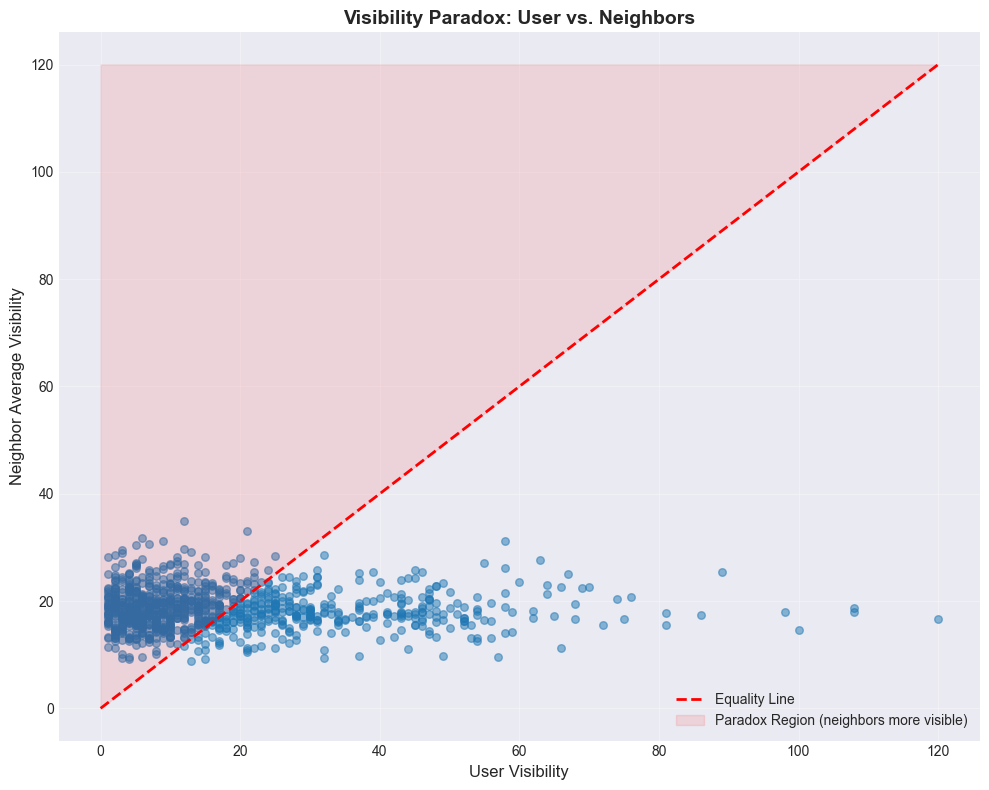

In [21]:
# Visualize user vs neighbor visibility
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(user_vis, neighbor_vis, alpha=0.5, s=30)
plt.xlabel('User Visibility', fontsize=12)
plt.ylabel('Neighbor Average Visibility', fontsize=12)
plt.title('Visibility Paradox: User vs. Neighbors', fontsize=14, fontweight='bold')

# Add diagonal line (equality)
max_val = max(max(user_vis), max(neighbor_vis))
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Equality Line')

# Shade paradox region
plt.fill_between([0, max_val], [0, max_val], max_val, alpha=0.1, color='red', 
                 label='Paradox Region (neighbors more visible)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Recommendation System Metrics

### Engagement Momentum

Measures how consistently users engage with recommended content over time.

In [22]:
# Calculate engagement momentum
# time_window_rounds specifies how many rounds to analyze
momentum = engagement_momentum(ydh, time_window_rounds=24)

print("Engagement Momentum Analysis:")
print(f"  Users analyzed: {len(momentum)}")
print(f"  Average momentum: {np.mean(list(momentum.values())):.4f}")
print(f"  Median momentum: {np.median(list(momentum.values())):.4f}")

# Show top 5 users by momentum
top_momentum = sorted(momentum.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Users by Engagement Momentum:")
for i, (user, score) in enumerate(top_momentum, 1):
    print(f"  {i}. User {user}: {score:.4f}")

Engagement Momentum Analysis:
  Users analyzed: 17659
  Average momentum: 1.7804
  Median momentum: 0.9986

Top 5 Users by Engagement Momentum:
  1. User 200: 30.4290
  2. User 785: 28.3261
  3. User 880: 28.2236
  4. User 885: 27.7070
  5. User 192: 27.1435


### Personalization Balance Score

Measures how well the recommendation system balances exploration vs. exploitation.

In [23]:
# Calculate personalization balance
balance_scores = personalization_balance_score(ydh)

print("Personalization Balance Analysis:")
print(f"  Users analyzed: {len(balance_scores)}")
print(f"  Average balance: {np.mean(list(balance_scores.values())):.4f}")
print(f"  Median balance: {np.median(list(balance_scores.values())):.4f}")
print("\nInterpretation:")
print("  Score → 0: Heavy exploitation (narrow recommendations)")
print("  Score → 1: Heavy exploration (diverse recommendations)")

Personalization Balance Analysis:
  Users analyzed: 975
  Average balance: 0.0065
  Median balance: 0.0000

Interpretation:
  Score → 0: Heavy exploitation (narrow recommendations)
  Score → 1: Heavy exploration (diverse recommendations)


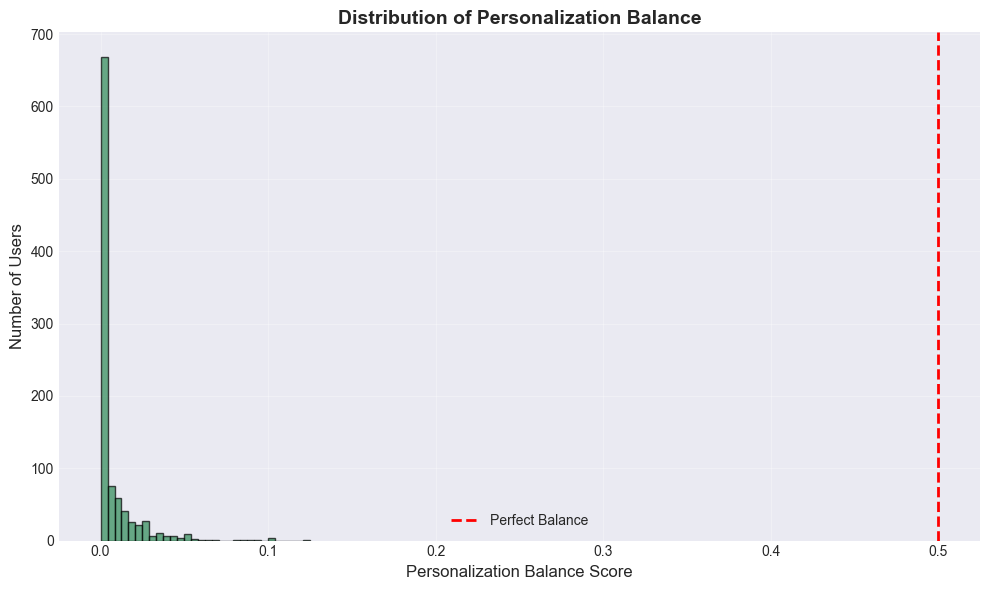

In [24]:
# Visualize balance distribution
plt.figure(figsize=(10, 6))
plt.hist(list(balance_scores.values()), bins=30, edgecolor='black', alpha=0.7, color='seagreen')
plt.xlabel('Personalization Balance Score', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.title('Distribution of Personalization Balance', fontsize=14, fontweight='bold')
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Perfect Balance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In this tutorial, you learned:

✓ How to measure profile similarity across the network  
✓ Detecting and analyzing the visibility paradox  
✓ Computing recommendation system metrics (engagement momentum, personalization balance)  

## Next Steps

- **Visualization Tutorial**: Create publication-ready visualizations using ySights' viz module